## 1. Load features and inspect per bearing
This cell loads time domain features for the 2nd test dataset.
One row is one measurement in time.
Each table shows the first 5 rows for one bearing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/2nd_test/'
df = extract_features(DATA_DIR)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std
Time,,,,,,
2004-02-12 10:32:39,0.074179,0.628763,6.120331,0.454,0.083993,0.073475
2004-02-12 10:42:39,0.075382,0.648291,5.147086,0.388,0.052142,0.075338
2004-02-12 10:52:39,0.076230,0.513475,6.598472,0.503,0.032808,0.076189
2004-02-12 11:02:39,0.078724,1.157953,7.723217,0.608,0.041486,0.078691
2004-02-12 11:12:39,0.078474,0.603177,4.982524,0.391,0.028224,0.078437


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std
Time,,,,,,
2004-02-12 10:32:39,0.090944,0.506801,5.640841,0.513,0.126915,0.090053
2004-02-12 10:42:39,0.093419,0.253014,5.148852,0.481,0.070088,0.093384
2004-02-12 10:52:39,0.093718,0.310789,5.367171,0.503,0.096583,0.093703
2004-02-12 11:02:39,0.092947,0.235341,6.121762,0.569,0.105834,0.092916
2004-02-12 11:12:39,0.095348,0.226309,5.097120,0.486,0.097966,0.095335


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std
Time,,,,,,
2004-02-12 10:32:39,0.109404,3.213075,9.350652,1.023,0.204840,0.108434
2004-02-12 10:42:39,0.109817,1.395250,6.847735,0.752,-0.023854,0.109790
2004-02-12 10:52:39,0.109861,2.639948,8.492546,0.933,0.056561,0.109849
2004-02-12 11:02:39,0.110667,2.682779,9.180734,1.016,0.033550,0.110622
2004-02-12 11:12:39,0.107506,1.578395,7.171719,0.771,-0.002892,0.107499


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std
Time,,,,,,
2004-02-12 10:32:39,0.054103,0.065959,4.879539,0.264,-0.022080,0.053166
2004-02-12 10:42:39,0.056101,0.107539,4.438435,0.249,0.001582,0.055973
2004-02-12 10:52:39,0.056145,0.257236,6.305078,0.354,0.070449,0.056037
2004-02-12 11:02:39,0.056807,0.806190,9.241749,0.525,-0.036327,0.056684
2004-02-12 11:12:39,0.056841,0.138954,4.292680,0.244,0.019008,0.056777


## 2. RMS over the full timeline

This plot shows RMS for all bearings across the whole test.
Flat and low means healthy. A sharp rise means the fault starts.

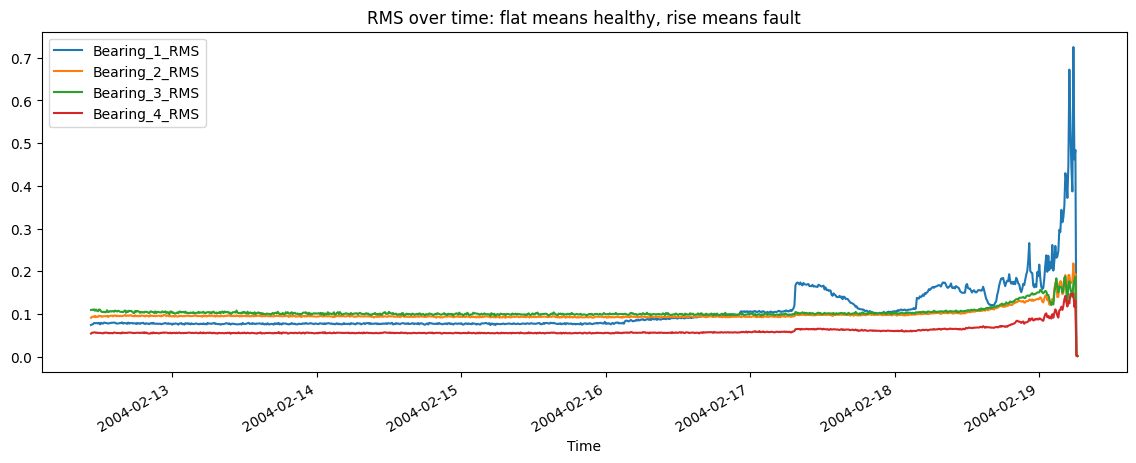

In [2]:
rms_cols = [c for c in df.columns if 'RMS' in c]
df[rms_cols].plot(figsize=(14, 5))
plt.title('RMS over time: flat means healthy, rise means fault')
plt.legend()
plt.show()

## 3. Faulty bearing in detail
Bearing 1 is the one that fails in the 2nd test.
Each feature has its own plot because features use different scales.
Look at which feature reacts first when the fault starts.

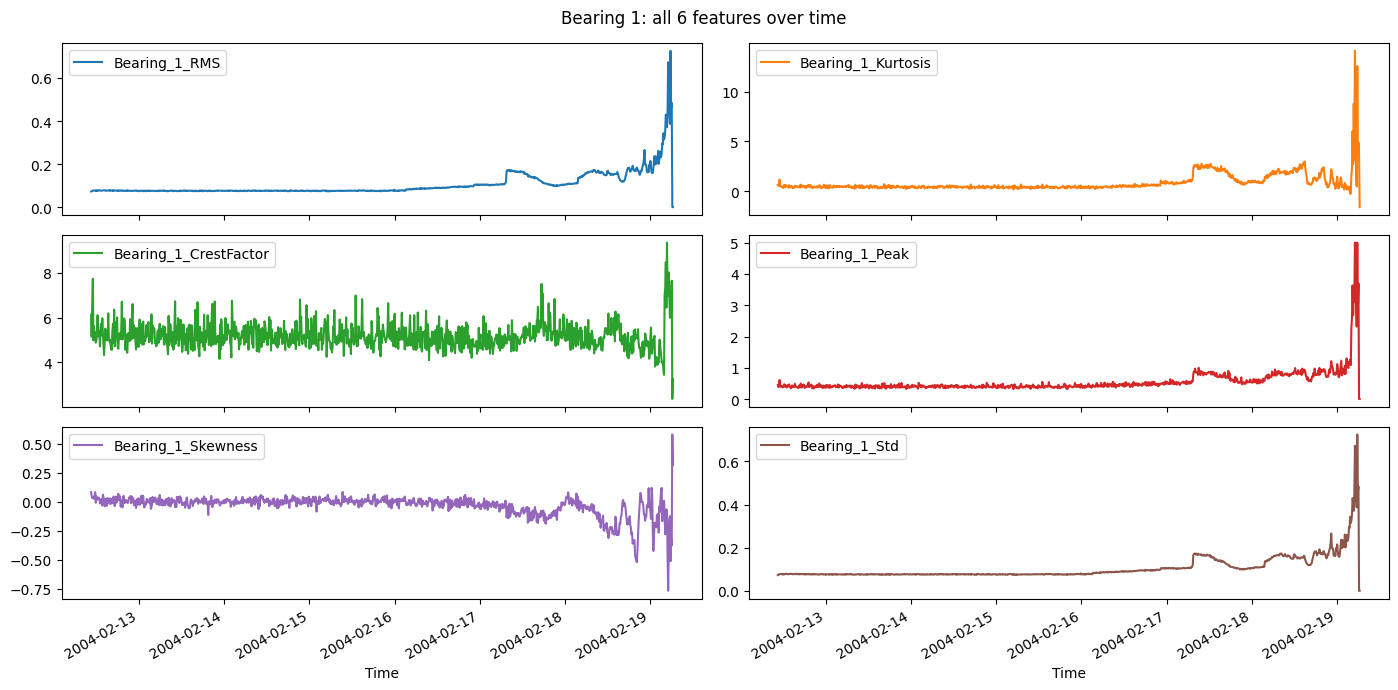

In [3]:
bearing1_cols = [c for c in df.columns if 'Bearing_1_' in c]
df[bearing1_cols].plot(figsize=(14, 7), subplots=True, layout=(3, 2))
plt.suptitle('Bearing 1: all 6 features over time')
plt.tight_layout()
plt.show()

## 4. Compare healthy boundary candidates
Try several boundary dates on Bearing_1_RMS and compare them side by side.
A good boundary keeps FPR low while giving enough healthy samples for training.
If the first alarm moves later when the boundary moves later, the boundary
has swallowed the start of the fault and is too late.

In [4]:
from src.evaluation import compare_boundaries

scores = df['Bearing_1_RMS']
candidates = [
    pd.Timestamp('2004-02-14 12:00:00'),
    pd.Timestamp('2004-02-14 18:00:00'),
    pd.Timestamp('2004-02-15 00:00:00'),
    pd.Timestamp('2004-02-15 06:00:00'),
    pd.Timestamp('2004-02-15 12:00:00'),
    pd.Timestamp('2004-02-16 00:00:00'),
    pd.Timestamp('2004-02-16 06:00:00'),
    pd.Timestamp('2004-02-16 12:00:00'),
    pd.Timestamp('2004-02-16 18:00:00'),
    pd.Timestamp('2004-02-17 00:00:00'),
]
compare_boundaries(scores, candidates)

,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-02-14 12:00:00,297,0.080486,2004-02-16 06:22:39,0.000000
1,2004-02-14 18:00:00,333,0.080461,2004-02-16 06:22:39,0.000000
2,2004-02-15 00:00:00,369,0.080421,2004-02-16 06:22:39,0.000000
3,2004-02-15 06:00:00,405,0.080460,2004-02-16 06:22:39,0.000000
4,2004-02-15 12:00:00,441,0.080361,2004-02-16 06:22:39,0.000000
5,2004-02-16 00:00:00,513,0.080459,2004-02-16 06:22:39,0.001949
6,2004-02-16 06:00:00,549,0.082455,2004-02-16 06:32:39,0.029144
7,2004-02-16 12:00:00,585,0.087362,2004-02-16 12:32:39,0.044444
8,2004-02-16 18:00:00,621,0.092661,2004-02-16 18:32:39,0.027375
9,2004-02-17 00:00:00,657,0.099424,2004-02-17 01:32:39,0.015221


### Reading the table above

- **Rows for 2004-02-14 12:00 through 2004-02-16 00:00** (6 candidates):
  threshold stays flat (~0.0804), first_alarm is identical every time
  (2004-02-16 06:22:39), FPR stays near zero. This means the fault has NOT
  started yet in this range - safe to use as "healthy" training data.
- **Rows from 2004-02-16 06:00 onward**: threshold keeps rising
  (0.082 -> 0.099), and first_alarm keeps shifting later (06:32 -> 12:32 ->
  18:32 -> next day 01:32). This is the signature of contamination: the
  fault has already begun, so including this period as "healthy" trains the
  model to treat early fault symptoms as normal, delaying detection.
- **Conclusion**: the widest safe boundary is 2004-02-16 00:00:00 - the last
  candidate before results start changing.

## 5. Decision: chosen healthy boundary

We choose 2004-02-16 00:00:00 (513 healthy samples) - the widest boundary
that still gives stable results, per the interpretation above.

In [5]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-02-16')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-02-16 00:00:00


## 6. Split into healthy / full dataset

Using the boundary chosen above. Every model from here on trains ONLY on
this healthy subset - never sees the fault during training.

In [6]:
from src.preprocessing import split_healthy, scale_features

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
print(f"Healthy samples: {len(df_healthy)} out of {len(df)}")
print(f"Healthy period: {df_healthy.index[0]} to {df_healthy.index[-1]}")

X_healthy, X_all, scaler = scale_features(df_healthy, df)
input_dim = X_healthy.shape[1]
print(f"Feature dimension: {input_dim}")

Healthy samples: 513 out of 984
Healthy period: 2004-02-12 10:32:39 to 2004-02-15 23:52:39
Feature dimension: 24
